Implementação do primeiro trabalho de Mineração de Dados

In [ ]:
%%capture
#Primera etapa: Instalação das bibliotecas
%pip install pandas numpy matplotlib scikit-learn

In [ ]:
#Verifica se as bibliotecas estão funcionando
import pandas as pd
import sklearn
import matplotlib

print("Tudo OK!")
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)

Tudo OK!
Pandas: 3.0.5
Scikit-learn: 1.9.1
Matplotlib: 3.11.2


In [ ]:
#Segunda etapa: Guardar informações: dependências, bibliotecas C compiladores e também pacotes 
#instalados via pip.
%pip freeze > requirements.txt

#Terceira etapa: carregar a  base de dados

In [3]:
#Carregar a base de dados
from pathlib import Path
import pandas as pd

# Caminho do arquivo
arquivo = Path("Dry_Bean_Dataset.xlsx")

# Verifica se o arquivo existe
print("Arquivo encontrado:", arquivo.exists())

# Carrega a base de dados Excel
df = pd.read_excel(arquivo)

# Visualiza as primeiras linhas
df.head()

Arquivo encontrado: True


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


Quarta etapa: pré-processamento

In [4]:
#Tratar valores ausentes

# Quantidade de valores ausentes por coluna
df.isnull().sum()

print("Total de valores ausentes:", df.isnull().sum().sum())

Total de valores ausentes: 0


Apesar de não haver valores ausentes foi desenvolvido scripts para tratar caso houvesse 

In [5]:
#Tratar os valores ausentes (se houver)

#Para colunas numéricas
colunas_numericas = df.select_dtypes(include="number").columns

for coluna in colunas_numericas:
    df[coluna] = df[coluna].fillna(df[coluna].median())

#Para colunas categóricas (caso existam)
colunas_categoricas = df.select_dtypes(exclude="number").columns

for coluna in colunas_categoricas:
    df[coluna] = df[coluna].fillna(df[coluna].mode()[0])

#Confirmar o resultado
df.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

In [6]:
#Tratar valores duplicados
# Quantidade de linhas duplicadas
duplicatas = df.duplicated().sum()

print(f"Quantidade de registros duplicados: {duplicatas}")

Quantidade de registros duplicados: 68


In [7]:
# Exibe as linhas duplicadas
df[df.duplicated()]

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
5505,33518,702.956,277.571399,154.305581,1.798842,0.831240,34023,206.582775,0.808383,0.985157,0.852377,0.744251,0.008281,0.001567,0.553909,0.996396,HOROZ
5509,33954,716.750,277.368480,156.356326,1.773951,0.825970,34420,207.922042,0.799482,0.986461,0.830549,0.749624,0.008169,0.001591,0.561936,0.996847,HOROZ
5548,38427,756.323,306.533886,160.591784,1.908777,0.851782,38773,221.193978,0.796976,0.991076,0.844174,0.721597,0.007977,0.001334,0.520702,0.993905,HOROZ
5554,38891,791.343,319.499996,156.869619,2.036723,0.871168,39651,222.525412,0.650025,0.980833,0.780422,0.696480,0.008215,0.001192,0.485085,0.987983,HOROZ
5599,40804,790.802,323.475648,163.287717,1.981016,0.863241,41636,227.932592,0.787570,0.980017,0.819931,0.704636,0.007928,0.001206,0.496512,0.983598,HOROZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7263,63408,1005.966,412.551649,196.337705,2.101235,0.879494,64200,284.136539,0.798791,0.987664,0.787385,0.688730,0.006506,0.000903,0.474348,0.996718,HOROZ
7278,63882,1004.206,411.263403,198.765453,2.069089,0.875452,64663,285.196579,0.754705,0.987922,0.796054,0.693465,0.006438,0.000918,0.480893,0.995010,HOROZ
7285,63948,996.497,412.297178,198.877557,2.073121,0.875971,64641,285.343867,0.777909,0.989279,0.809254,0.692083,0.006447,0.000912,0.478979,0.992981,HOROZ
7340,65766,1035.842,406.416622,207.242369,1.961069,0.860218,66698,289.371512,0.792295,0.986027,0.770237,0.712007,0.006180,0.000980,0.506954,0.994172,HOROZ


In [8]:
# Remove registros duplicados
df = df.drop_duplicates()

print(f"Quantidade de registros após a remoção: {len(df)}")
print(f"Duplicatas restantes: {df.duplicated().sum()}")

Quantidade de registros após a remoção: 13543
Duplicatas restantes: 0


Verificar distribuição das classes A distribuição das classes permite verificar se o conjunto está balanceado ou se alguma classe possui poucas amostras. A variável alvo é a coluna Class, que contém as 7 classes (SEKER, BARBUNYA, BOMBAY, CALI, DERMASON, HOROZ e SIRA). Essa etapa do pré-processamento serve para verificar se as classes estão balanceadas antes de dividir os dados em treino e teste.

In [9]:
#Contar a quantidade de amostras por classe
distribuicao = df["Class"].value_counts().sort_values(ascending=False)

print(distribuicao)

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


A saída mostrará quantas amostras existem em cada uma das sete classes

In [10]:
#Calcular o percentual de cada classe
percentual = (df["Class"].value_counts(normalize=True) * 100).round(2)

print(percentual)

Class
DERMASON    26.18
SIRA        19.46
SEKER       14.97
HOROZ       13.73
CALI        12.04
BARBUNYA     9.76
BOMBAY       3.85
Name: proportion, dtype: float64


In [11]:
#Criar uma tabela resumida
tabela_classes = df["Class"].value_counts().to_frame(name="Quantidade")

tabela_classes["Percentual (%)"] = (
    df["Class"].value_counts(normalize=True) * 100
).round(2)

tabela_classes

,Quantidade,Percentual (%)
Class,,
DERMASON,3546,26.18
SIRA,2636,19.46
SEKER,2027,14.97
HOROZ,1860,13.73
CALI,1630,12.04
BARBUNYA,1322,9.76
BOMBAY,522,3.85


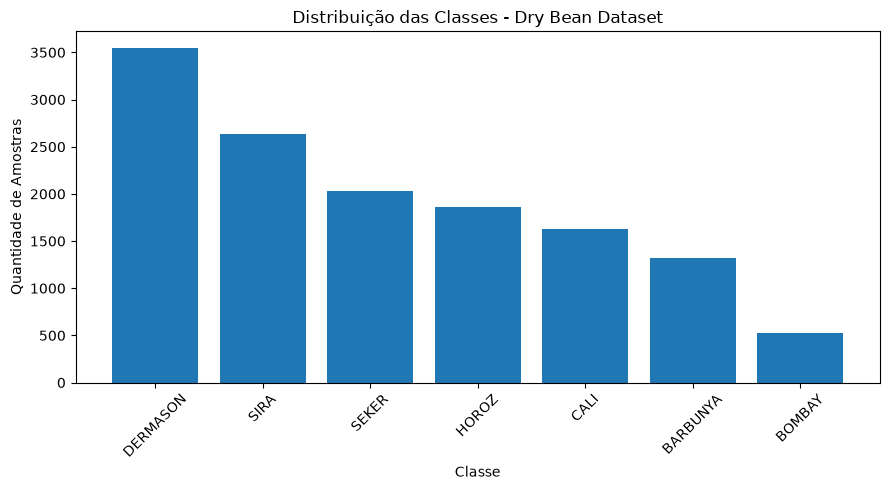

In [12]:
#Visualizar a distribuição em gráfico
import matplotlib.pyplot as plt

contagem = df["Class"].value_counts()

plt.figure(figsize=(9,5))
plt.bar(contagem.index, contagem.values)

plt.title("Distribuição das Classes - Dry Bean Dataset")
plt.xlabel("Classe")
plt.ylabel("Quantidade de Amostras")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Foi analisada a distribuição da variável alvo Class, contabilizando o número de amostras e o percentual correspondente a cada uma das sete classes do conjunto Dry Bean. Essa verificação permite identificar o grau de balanceamento da base e justifica a utilização da divisão estratificada (stratify=y) na separação entre conjuntos de treinamento e teste, preservando a proporção das classes durante a avaliação dos modelos.

Quinta etapa: Codificar a variável alvo (LabelEncoder). Converter a variável alvo em número.

In [13]:
#Importar o LabelEncoder
from sklearn.preprocessing import LabelEncoder

In [14]:
#Visualizar as classes originais
print("Classes originais:")
print(sorted(df["Class"].unique()))

Classes originais:
['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


In [15]:
#Aplicar o LabelEncoder
# Cria o codificador
encoder = LabelEncoder()

# Codifica a variável alvo
df["Class"] = encoder.fit_transform(df["Class"])

# Visualiza as primeiras linhas
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,5
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,5
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,5
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,5
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,5


In [16]:
#Verificar o mapeamento das classes
for codigo, classe in enumerate(encoder.classes_):
    print(f"{codigo} → {classe}")

0 → BARBUNYA
1 → BOMBAY
2 → CALI
3 → DERMASON
4 → HOROZ
5 → SEKER
6 → SIRA


A numeração é definida automaticamente em ordem alfabética das classes

In [17]:
#Confirmar que a distribuição foi preservada
df["Class"].value_counts().sort_index()

Class
0    1322
1     522
2    1630
3    3546
4    1860
5    2027
6    2636
Name: count, dtype: int64

A variável alvo Class, originalmente representada por rótulos textuais das sete variedades de feijão, foi convertida para valores numéricos utilizando o LabelEncoder da biblioteca scikit-learn. Essa transformação preserva a correspondência entre as classes e permite que os algoritmos de classificação processem corretamente a variável alvo.

Separar atributos (X) e classe (y). Prepara os dados para o treinamento dos modelos
Separar:
X: todas as colunas preditoras (16 atributos numéricos)
y: a coluna Class, que é a variável alvo

In [18]:
# Separa os atributos (X) e a variável alvo (y)
X = df.drop("Class", axis=1)
y = df["Class"]

In [19]:
#Verificar as dimensões
print("Dimensões de X:", X.shape)
print("Dimensões de y:", y.shape)

Dimensões de X: (13543, 16)
Dimensões de y: (13543,)


In [20]:
#Conferir os atributos
print("Atributos utilizados:")
print(X.columns.tolist())

Atributos utilizados:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']


Lista as 16 características que serão utilizadas pelos algoritmos de classificação

In [21]:
#Conferir a variável alvo
print("Primeiros valores de y:")
print(y.head())

Primeiros valores de y:
0    5
1    5
2    5
3    5
4    5
Name: Class, dtype: int64


Após o pré-processamento, o conjunto de dados foi dividido em duas partes: X, contendo 
os 16 atributos preditores do Dry Bean Dataset, e y, correspondente à variável alvo 
Class, previamente codificada em valores numéricos com LabelEncoder. Essa separação é 
necessária para que os algoritmos de classificação recebam corretamente as entradas 
(atributos) e as saídas (classes).

Sexta etapa: Separação do conjunto de dados (Holdout).
Separação dos dados. 
divisão do conjunto em treino e teste (train_test_split) utilizando stratify=y, preservando a proporção das sete classes nos dois conjuntos antes de treinar Árvore de Decisão, Bagging, AdaBoost e Random Forest

In [22]:
#Importar a função train_test_split
from sklearn.model_selection import train_test_split

In [23]:
#Dividir em treino e teste. 70% para treinamento e 30% para teste
## Divisão Holdout
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [24]:
#Verificar as dimensões
print("Conjunto de Treinamento")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nConjunto de Teste")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Conjunto de Treinamento
X_train: (9480, 16)
y_train: (9480,)

Conjunto de Teste
X_test: (4063, 16)
y_test: (4063,)


In [25]:
#Confirmar que as classes foram preservadas
print("Treinamento (%):")
print((y_train.value_counts(normalize=True) * 100).round(2).sort_index())

print("\nTeste (%):")
print((y_test.value_counts(normalize=True) * 100).round(2).sort_index())

Treinamento (%):
Class
0     9.76
1     3.86
2    12.04
3    26.18
4    13.73
5    14.97
6    19.46
Name: proportion, dtype: float64

Teste (%):
Class
0     9.77
1     3.84
2    12.04
3    26.19
4    13.73
5    14.96
6    19.47
Name: proportion, dtype: float64


O conjunto de dados foi dividido utilizando a técnica Holdout, reservando 70% das amostras para treinamento e 30% para teste. A divisão foi realizada com random_state=42 para garantir a reprodutibilidade dos experimentos e com stratify=y para preservar a proporção das sete classes do Dry Bean Dataset em ambos os conjuntos.

Sétima etapa: Treinamento dos modelos

Treinamento do modelo Decision Tree
Nessa etapa serão utilizadas duas métricas principais:
1) Acurácia: percentual de classificações corretas.
2) F1-score (macro): média do F1 de todas as classes, sendo mais adequada para problemas multiclasse.

In [26]:
#Importar o algoritmo e as métricas
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [27]:
# Cria o modelo de Árvore de Decisão
modelo_dt = DecisionTreeClassifier(random_state=42)

In [28]:
# Treina o modelo com os dados de treinamento
modelo_dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

In [29]:
# Faz previsões no conjunto de teste
y_pred_dt = modelo_dt.predict(X_test)

In [30]:
#Avaliar o desempenho
# Calcula as métricas
acuracia_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average="macro")

print(f"Acurácia: {acuracia_dt:.4f}")
print(f"F1-Score (Macro): {f1_dt:.4f}")

Acurácia: 0.8924
F1-Score (Macro): 0.9076


In [31]:
#Relatório de classificação
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.89      0.88      0.88       397
           1       1.00      1.00      1.00       156
           2       0.89      0.92      0.91       489
           3       0.89      0.89      0.89      1064
           4       0.93      0.92      0.93       558
           5       0.91      0.95      0.93       608
           6       0.83      0.81      0.82       791

    accuracy                           0.89      4063
   macro avg       0.91      0.91      0.91      4063
weighted avg       0.89      0.89      0.89      4063



In [32]:
#Matriz de confusão
matriz = confusion_matrix(y_test, y_pred_dt)

print(matriz)

[[348   0  31   0   4   6   8]
 [  0 156   0   0   0   0   0]
 [ 25   0 449   0  11   1   3]
 [  0   0   0 942   5  20  97]
 [  7   0  19   3 514   0  15]
 [  4   0   0  15   0 579  10]
 [  7   0   3  98  18  27 638]]


<Figure size 800x800 with 0 Axes>

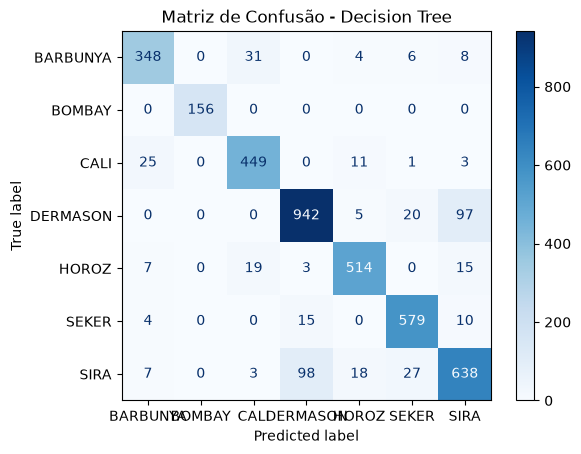

In [33]:
#Visualização da matriz de confusão
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8,8))

ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=encoder.classes_
).plot(cmap="Blues")

plt.title("Matriz de Confusão - Decision Tree")
plt.show()

Oitava etapa: Treinamento do modelo Bagging

In [34]:
#Importar as bibliotecas
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

In [35]:
#Criar o modelo Bagging. Foi utilizado Árvore de Decisão como estimador base
modelo_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)

In [36]:
#Treinar o modelo
modelo_bagging.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [37]:
#Realizar as previsões no conjunto de teste
y_pred_bagging = modelo_bagging.predict(X_test)

In [38]:
#Avaliar o desempenho. Calcula as métricas
acuracia_bagging = accuracy_score(y_test, y_pred_bagging)
f1_bagging = f1_score(y_test, y_pred_bagging, average="macro")

print(f"Acurácia: {acuracia_bagging:.4f}")
print(f"F1-Score (Macro): {f1_bagging:.4f}")

Acurácia: 0.9195
F1-Score (Macro): 0.9316


In [39]:
#Relatório de classificação. Apresenta, para cada uma das sete classes: (Precision, Recall,
# F1-score e Support)
print(classification_report(y_test, y_pred_bagging))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       397
           1       1.00      1.00      1.00       156
           2       0.93      0.93      0.93       489
           3       0.91      0.92      0.91      1064
           4       0.95      0.94      0.95       558
           5       0.93      0.95      0.94       608
           6       0.87      0.86      0.87       791

    accuracy                           0.92      4063
   macro avg       0.93      0.93      0.93      4063
weighted avg       0.92      0.92      0.92      4063



In [40]:
# Gera a matriz de confusão
matriz_bagging = confusion_matrix(y_test, y_pred_bagging)
print(matriz_bagging)

[[360   0  20   0   3   6   8]
 [  0 156   0   0   0   0   0]
 [ 18   0 456   0  10   2   3]
 [  0   0   0 974   0  21  69]
 [  3   0  11   6 527   0  11]
 [  4   0   0  11   0 580  13]
 [  4   0   1  79  12  12 683]]


<Figure size 800x800 with 0 Axes>

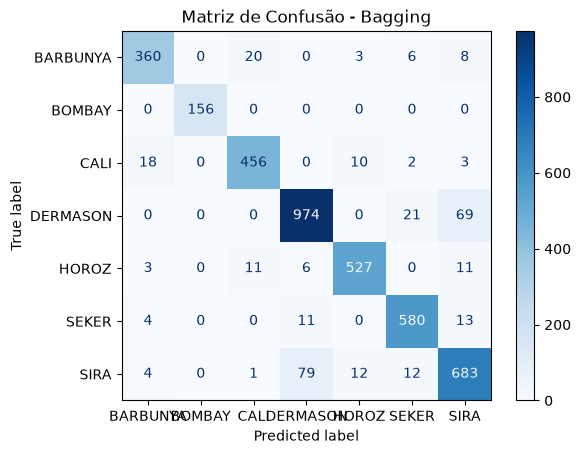

In [41]:
#Visualizar a matriz de confusão
plt.figure(figsize=(8,8))

ConfusionMatrixDisplay(
    confusion_matrix=matriz_bagging,
    display_labels=encoder.classes_
).plot(cmap="Blues")

plt.title("Matriz de Confusão - Bagging")
plt.show()

O modelo Bagging foi implementado utilizando BaggingClassifier com uma Árvore de Decisão como estimador base e 100 árvores (n_estimators=100). O desempenho foi avaliado no conjunto de teste por meio das métricas de acurácia e F1-score (macro), complementadas pelo relatório de classificação e pela matriz de confusão, permitindo sua comparação direta com a Árvore de Decisão treinada anteriormente.

Nona etapa: Treinamento do modelo AdaBoost

In [42]:
#Importar as bibliotecas
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

In [43]:
#Criar o modelo AdaBoost. Foi utilizado Árvore de Decisão com profundidade 1 
# (max_depth=1), que é a configuração tradicional do AdaBoost.
modelo_adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

In [44]:
#Treinar o modelo
modelo_adaboost.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](7,)","[0,1,2,...,4,5,6]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...ndom_state=42)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](100,)","[0.59,0.6 ,0.6 ,...,0.72,0.73,0.62]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](100,)","[1.43,1.37,1.38,...,0.85,0.81,1.31]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](16,)","[0.02,0.17,0.05,...,0.05,0.04,0.05]"


In [45]:
# Faz previsões no conjunto de teste
y_pred_adaboost = modelo_adaboost.predict(X_test)

In [46]:
#Avaliar o desempenho. Calcula as métricas
acuracia_adaboost = accuracy_score(y_test, y_pred_adaboost)
f1_adaboost = f1_score(y_test, y_pred_adaboost, average="macro")

print(f"Acurácia: {acuracia_adaboost:.4f}")
print(f"F1-Score (Macro): {f1_adaboost:.4f}")

Acurácia: 0.8671
F1-Score (Macro): 0.8780


In [47]:
#Relatório de classificação. Mostra cada uma das sete classes:Precision, Recall, 
# F1-score Support
print(classification_report(y_test, y_pred_adaboost))

              precision    recall  f1-score   support

           0       0.92      0.71      0.80       397
           1       1.00      1.00      1.00       156
           2       0.80      0.91      0.85       489
           3       0.86      0.90      0.88      1064
           4       0.91      0.95      0.93       558
           5       0.85      0.94      0.89       608
           6       0.87      0.73      0.79       791

    accuracy                           0.87      4063
   macro avg       0.89      0.88      0.88      4063
weighted avg       0.87      0.87      0.86      4063



In [48]:
# Gera a matriz de confusão
matriz_adaboost = confusion_matrix(y_test, y_pred_adaboost)

print(matriz_adaboost)

[[283   0  96   0   1   6  11]
 [  0 156   0   0   0   0   0]
 [ 11   0 447   0  27   2   2]
 [  0   0   0 961   2  56  45]
 [  4   0  13   4 530   0   7]
 [  7   0   0  12   0 569  20]
 [  4   0   1 144  25  40 577]]


<Figure size 800x800 with 0 Axes>

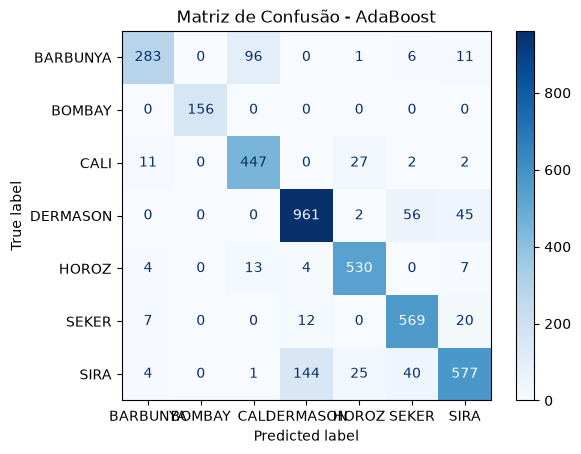

In [49]:
#Visualizar a matriz de confusão
plt.figure(figsize=(8,8))

ConfusionMatrixDisplay(
    confusion_matrix=matriz_adaboost,
    display_labels=encoder.classes_
).plot(cmap="Blues")

plt.title("Matriz de Confusão - AdaBoost")
plt.show()

O modelo AdaBoost foi implementado utilizando AdaBoostClassifier com uma Árvore de Decisão de profundidade 1 como estimador base, configuração tradicional do algoritmo. Foram utilizados 100 estimadores (n_estimators=100) e taxa de aprendizado igual a 1,0. O desempenho foi avaliado por meio das métricas de acurácia e F1-score (macro), além do relatório de classificação e da matriz de confusão.

Décima etapa: Treinamento do modelo Random Forest

In [50]:
#Importar as bibliotecas
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

In [51]:
#Criar o modelo. Foi utilizado uma configuração inicial simples, que 
#posteriormente poderá ser otimizada na etapa de ajuste de hiperparâmetros.
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [52]:
# Treina o modelo
modelo_rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [53]:
# Faz previsões no conjunto de teste
y_pred_rf = modelo_rf.predict(X_test)

In [54]:
#Avaliar o desempenho. Calcula as métricas
acuracia_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average="macro")

print(f"Acurácia: {acuracia_rf:.4f}")
print(f"F1-Score (Macro): {f1_rf:.4f}")

Acurácia: 0.9207
F1-Score (Macro): 0.9328


In [55]:
#Relatório de classificaçã0. Esse relatório apresenta, para cada uma das sete classes:
# Precision, Recall, F1-score e Support
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.93      0.90      0.92       397
           1       1.00      1.00      1.00       156
           2       0.93      0.93      0.93       489
           3       0.91      0.92      0.91      1064
           4       0.95      0.94      0.95       558
           5       0.94      0.96      0.95       608
           6       0.87      0.86      0.87       791

    accuracy                           0.92      4063
   macro avg       0.93      0.93      0.93      4063
weighted avg       0.92      0.92      0.92      4063



In [56]:
# Gera a matriz de confusão
matriz_rf = confusion_matrix(y_test, y_pred_rf)

print(matriz_rf)

[[359   0  20   0   3   7   8]
 [  0 156   0   0   0   0   0]
 [ 17   0 456   0  11   2   3]
 [  0   0   0 976   0  19  69]
 [  2   0  11   6 527   0  12]
 [  3   0   0  10   0 584  11]
 [  4   0   1  81  11  11 683]]


<Figure size 800x800 with 0 Axes>

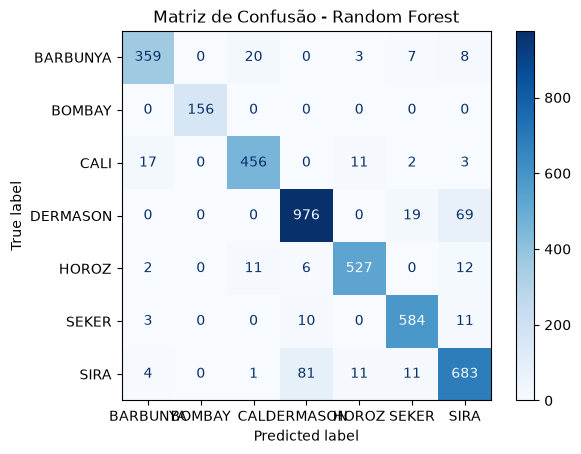

In [57]:
#Visualizar a matriz de confusão
plt.figure(figsize=(8,8))

ConfusionMatrixDisplay(
    confusion_matrix=matriz_rf,
    display_labels=encoder.classes_
).plot(cmap="Blues")

plt.title("Matriz de Confusão - Random Forest")
plt.show()

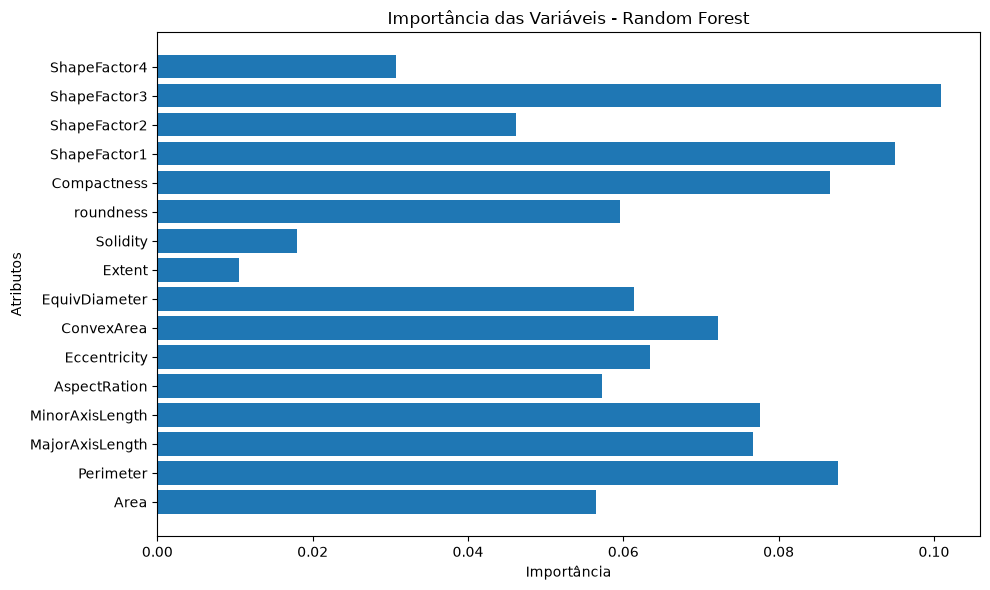

In [58]:
#Importância das variáveis. Uma vantagem do Random Forest é permitir identificar 
#quais atributos mais influenciaram a classificação.

importancias = modelo_rf.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(X.columns, importancias)
plt.xlabel("Importância")
plt.ylabel("Atributos")
plt.title("Importância das Variáveis - Random Forest")
plt.tight_layout()
plt.show()

Mostra quais características do Dry Bean Dataset tiveram maior contribuição para o modelo.

O modelo Random Forest foi implementado utilizando RandomForestClassifier com 100 
árvores (n_estimators=100) e random_state=42. O desempenho foi avaliado sobre o conjunto 
de teste utilizando as métricas de acurácia e F1-score (macro), além do relatório de 
classificação e da matriz de confusão. Adicionalmente, foi realizada a análise da importância das variáveis, permitindo identificar quais atributos exerceram maior influência na classificação das variedades de feijão.

Décimo primeiro: Avaliação dos Modelos

In [59]:
#Importar as métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import pandas as pd
import matplotlib.pyplot as plt

In [60]:
# Calcula as métricas de cada modelo
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

resultados = pd.DataFrame({
    "Modelo": [
        "Decision Tree",
        "Bagging",
        "AdaBoost",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_bagging),
        accuracy_score(y_test, y_pred_adaboost),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_dt, average="macro"),
        precision_score(y_test, y_pred_bagging, average="macro"),
        precision_score(y_test, y_pred_adaboost, average="macro"),
        precision_score(y_test, y_pred_rf, average="macro")
    ],
    "Recall": [
        recall_score(y_test, y_pred_dt, average="macro"),
        recall_score(y_test, y_pred_bagging, average="macro"),
        recall_score(y_test, y_pred_adaboost, average="macro"),
        recall_score(y_test, y_pred_rf, average="macro")
    ],
    "F1 Macro": [
        f1_score(y_test, y_pred_dt, average="macro"),
        f1_score(y_test, y_pred_bagging, average="macro"),
        f1_score(y_test, y_pred_adaboost, average="macro"),
        f1_score(y_test, y_pred_rf, average="macro")
    ]
}).round(4)

resultados

,Modelo,Accuracy,Precision,Recall,F1 Macro
0,Decision Tree,0.8924,0.9069,0.9086,0.9076
1,Bagging,0.9195,0.9324,0.9309,0.9316
2,AdaBoost,0.8671,0.8855,0.8779,0.8780
3,Random Forest,0.9207,0.9339,0.9318,0.9328


Identificar automaticamente o melhor modelo. Escolher o melhor modelo para ajustar hiperparâmetros, podemos fazer isso automaticamente usando o F1 Macro.

In [61]:
#melhor modelo
melhor_modelo = resultados.loc[resultados["F1 Macro"].idxmax()]

print("Melhor modelo:")
print(melhor_modelo)

Melhor modelo:
Modelo       Random Forest
Accuracy            0.9207
Precision           0.9339
Recall              0.9318
F1 Macro            0.9328
Name: 3, dtype: object


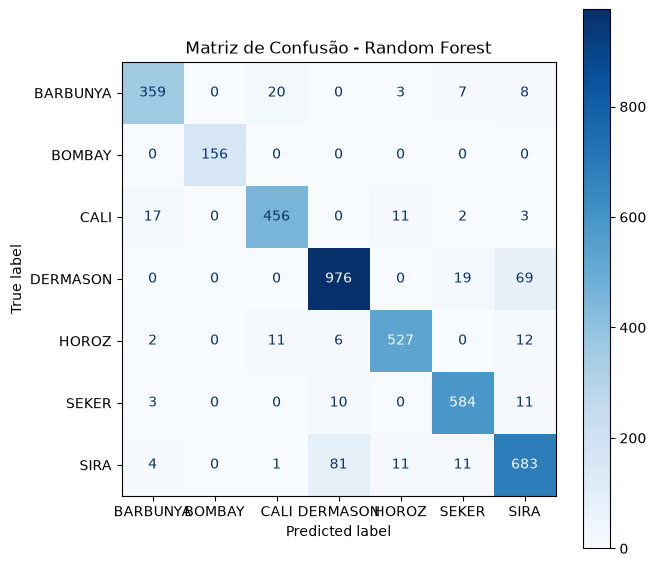

In [62]:
#Gerar a matriz de confusão apenas do melhor modelo
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

predicoes = {
    "Decision Tree": y_pred_dt,
    "Bagging": y_pred_bagging,
    "AdaBoost": y_pred_adaboost,
    "Random Forest": y_pred_rf
}

nome = melhor_modelo["Modelo"]
y_pred = predicoes[nome]

fig, ax = plt.subplots(figsize=(7,7))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=encoder.classes_
).plot(cmap="Blues", ax=ax)

ax.set_title(f"Matriz de Confusão - {nome}")
plt.show()

Relatório apenas do melhor modelo

In [63]:
#Função para gerar o relatório do melhor modelo
from sklearn.metrics import classification_report

print(f"Relatório de Classificação - {nome}")
print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

Relatório de Classificação - Random Forest
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.90      0.92       397
      BOMBAY       1.00      1.00      1.00       156
        CALI       0.93      0.93      0.93       489
    DERMASON       0.91      0.92      0.91      1064
       HOROZ       0.95      0.94      0.95       558
       SEKER       0.94      0.96      0.95       608
        SIRA       0.87      0.86      0.87       791

    accuracy                           0.92      4063
   macro avg       0.93      0.93      0.93      4063
weighted avg       0.92      0.92      0.92      4063



Visualização comparativa

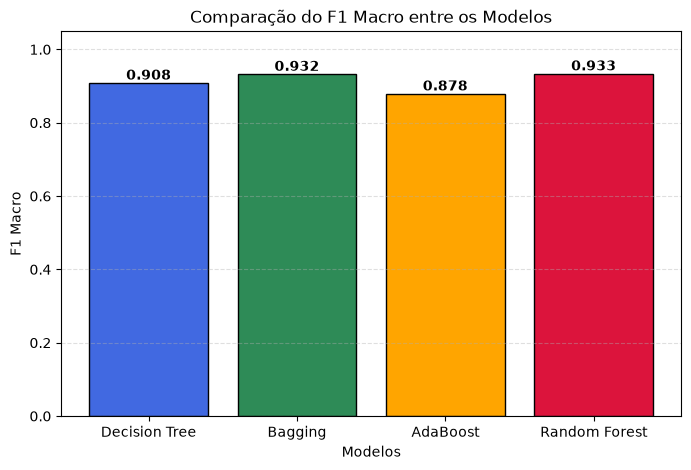

In [66]:
#Comparar o F1 Macro
import matplotlib.pyplot as plt

cores = ["royalblue", "seagreen", "orange", "crimson"]

plt.figure(figsize=(8,5))

barras = plt.bar(
    resultados["Modelo"],
    resultados["F1 Macro"],
    color=cores,
    edgecolor="black"
)

# Escreve o valor sobre cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura + 0.01,
        f"{altura:.3f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Comparação do F1 Macro entre os Modelos")
plt.xlabel("Modelos")
plt.ylabel("F1 Macro")
plt.ylim(0,1.05)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

Os quatro algoritmos foram avaliados utilizando as métricas Accuracy, Precision (macro), Recall (macro) e F1-score (macro). O F1-score macro foi adotado como principal critério de comparação por considerar igualmente o desempenho em todas as sete classes do Dry Bean Dataset. Além das métricas numéricas, foram analisadas as matrizes de confusão e os relatórios de classificação, permitindo identificar as classes com maior incidência de erros de classificação e comparar o comportamento individual de cada modelo.

Décima segunda etapa: Otimização com GridSearchCV

In [67]:
#Importar as bibliotecas
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [68]:
#Descobrir qual modelo venceu, ou seja, qual modelo teve o maior F1 Macro
nome_modelo = resultados.loc[resultados["F1 Macro"].idxmax(), "Modelo"]

print(f"Modelo selecionado para otimização: {nome_modelo}")

Modelo selecionado para otimização: Random Forest


In [69]:
#Definir automaticamente a grade de hiperparâmetros
# Seleciona o modelo e a grade de parâmetros automaticamente

if nome_modelo == "Decision Tree":

    modelo = DecisionTreeClassifier(random_state=42)

    parametros = {
        "criterion": ["gini", "entropy"],
        "max_depth": [5, 10, 20, None],
        "min_samples_split": [2, 5, 10]
    }

elif nome_modelo == "Bagging":

    modelo = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    )

    parametros = {
        "n_estimators": [50, 100, 150],
        "max_samples": [0.7, 0.9, 1.0],
        "max_features": [0.7, 1.0]
    }

elif nome_modelo == "AdaBoost":

    modelo = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        random_state=42
    )

    parametros = {
        "n_estimators": [50, 100, 150],
        "learning_rate": [0.1, 0.5, 1.0]
    }

else:  # Random Forest

    modelo = RandomForestClassifier(random_state=42)

    parametros = {
        "n_estimators": [50, 100, 200],
        "max_depth": [10, 20, None],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    }

In [70]:
#Executar o GridSearchCV
grid = GridSearchCV(
    estimator=modelo,
    param_grid=parametros,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbos

In [71]:
#Mostrar os melhores hiperparâmetros
print("Melhores hiperparâmetros encontrados:")

for chave, valor in grid.best_params_.items():
    print(f"{chave}: {valor}")

print(f"\nMelhor F1 na validação cruzada: {grid.best_score_:.4f}")

Melhores hiperparâmetros encontrados:
max_depth: 20
min_samples_leaf: 2
min_samples_split: 2
n_estimators: 200

Melhor F1 na validação cruzada: 0.9363


In [72]:
#Avaliar o modelo otimizado
# Melhor modelo encontrado
melhor_modelo_otimizado = grid.best_estimator_

# Faz previsões
y_pred_otimizado = melhor_modelo_otimizado.predict(X_test)

# Calcula as métricas
accuracy_otimizado = accuracy_score(y_test, y_pred_otimizado)
precision_otimizado = precision_score(y_test, y_pred_otimizado, average="macro")
recall_otimizado = recall_score(y_test, y_pred_otimizado, average="macro")
f1_otimizado = f1_score(y_test, y_pred_otimizado, average="macro")

print(f"Accuracy : {accuracy_otimizado:.4f}")
print(f"Precision: {precision_otimizado:.4f}")
print(f"Recall   : {recall_otimizado:.4f}")
print(f"F1 Macro : {f1_otimizado:.4f}")

Accuracy : 0.9207
Precision: 0.9344
Recall   : 0.9322
F1 Macro : 0.9332


In [73]:
#Comparar antes e depois
# Recupera o F1 do modelo original
f1_original = resultados.loc[
    resultados["Modelo"] == nome_modelo,
    "F1 Macro"
].values[0]

comparacao = {
    "Modelo": nome_modelo,
    "F1 Original": round(f1_original, 4),
    "F1 Otimizado": round(f1_otimizado, 4)
}

print(pd.DataFrame([comparacao]))

          Modelo  F1 Original  F1 Otimizado
0  Random Forest       0.9328        0.9332
